In [23]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns
import mne
import pyvista as pv
from mne.viz import Brain
from mne_bids import BIDSPath
from scipy.spatial import cKDTree
from tqdm import tqdm

In [24]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')

'notebook'

# Fig 1: Whole brain electrodes map to the pial surface

In [25]:
def insula_mask(df, atlas):
    """Boolean mask for insula electrodes (aparc: INS/Insula; hammers: pure AIC/PIC)."""
    if atlas in ('aparc', 'aparc2009s'):
        return df['roi'].isin({'INS', 'Insula'})
    mask = df['roi'].isin({'AIC', 'PIC'})
    if 'mix' in df.columns:
        mask = mask & ~df['mix'].fillna(False).astype(bool)
    return mask


task = [
    'PhonemeSequence',
    'LexicalDelay',
    'LexicalNoDelay',
    'PictureNaming',
]
ref = 'bipolar'
atlas = 'hammers'

coord_paths = []
for t in task:
    coord_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})({atlas})',
            datatype='HGA',
            suffix='coord',
            check=False,
        ).match()
    )

if not coord_paths:
    raise FileNotFoundError(
        f'No coord CSVs under results/{{task}}({ref})({atlas})/ for tasks={task}'
    )

coords = []
for path in tqdm(coord_paths, desc='load coord'):
    coords.append(pd.read_csv(path))
coords = pd.concat(coords, ignore_index=True)

coords = coords.dropna(subset=['x', 'y', 'z'])
coords_unique = coords.drop_duplicates(subset=['channel']).copy()
coords_unique['is_insula'] = insula_mask(coords_unique, atlas)

print(
    f'Unique electrodes: {len(coords_unique)} | '
    f'insula: {coords_unique["is_insula"].sum()}'
)
coords_unique.head()

load coord: 100%|██████████| 1203/1203 [00:03<00:00, 360.26it/s]


Unique electrodes: 13933 | insula: 442


,channel,label,roi,hemi,x,y,z,x_native,y_native,z_native,...,mix,HGA,significant,subject,task,band,description,phase,modality,is_insula
0,D0019_RIIH1-2,OL lingual gyrus R,LinG,R,8.41703,-44.3481,-20.64296,4.716095,-54.392452,0.147654,...,False,0.030667,False,D0019,PhonemeSequence,highgamma,Repeat,Delay,sound,False
1,D0019_RIIH2-3,OL lingual gyrus R,LinG,R,4.62597,-55.4648,-17.93574,0.886618,-64.005392,1.486429,...,False,-0.020306,False,D0019,PhonemeSequence,highgamma,Repeat,Delay,sound,False
2,D0019_RIIH3-4,OL lingual gyrus R,LinG,R,4.06682,-64.4239,-15.98172,0.380854,-73.247540,3.690883,...,False,-0.048647,False,D0019,PhonemeSequence,highgamma,Repeat,Delay,sound,False
3,D0019_RIIH4-5,OL cuneus R,LinG–Cun,R,5.34089,-73.6314,-12.22795,2.075648,-82.580128,7.017103,...,True,-0.038827,False,D0019,PhonemeSequence,highgamma,Repeat,Delay,sound,False
4,D0019_RLOS1-2,PL angular gyrus R,AG,R,52.64330,-39.8362,33.99210,47.479672,-54.131336,50.354019,...,False,0.087981,False,D0019,PhonemeSequence,highgamma,Repeat,Delay,sound,False


In [26]:
# Hammers MNI152 insula highlight on cvs_avg35_inMNI152 pial surface.
# Pial vertices and electrode x/y/z are CVS tkRAS; Hammers maxprob volume is MNI152 RAS.
import re
import nibabel as nib
from mne import Label

FS_SUBJECT = 'cvs_avg35_inMNI152'
HAMMERS_MNI152_PATH = (
    '/cwork/ns458/atlases/Hammersmith_n30r95/derivatives/faillenot_spm_mni152'
    '/probability_maps/Hammers-n30r95-maxprob-full-MNI152.nii.gz'
)
# Full Hammers insula = six gyri (bilateral). Same as slice_render.MAPER_INSULA_IDS.
HAMMERS_INSULA_INDEX = {
    20: 'posterior long gyrus',
    21: 'posterior long gyrus',
    86: 'anterior short gyrus',
    87: 'anterior short gyrus',
    88: 'middle short gyrus',
    89: 'middle short gyrus',
    90: 'posterior short gyrus',
    91: 'posterior short gyrus',
    92: 'anterior pole',
    93: 'anterior pole',
    94: 'anterior long gyrus',
    95: 'anterior long gyrus',
}
HAMMERS_INSULA_IDS = frozenset(HAMMERS_INSULA_INDEX)
# Packaged roi crosswalk (docs/PARCELLATION_PIPELINE.md).
HAMMERS_AIC_IDS = frozenset({86, 87, 88, 89, 90, 91, 92, 93})
HAMMERS_PIC_IDS = frozenset({94, 95, 20, 21})
HAMMERS_GYRUS_TO_IDS = {
    'anterior short gyrus': frozenset({86, 87}),
    'middle short gyrus': frozenset({88, 89}),
    'posterior short gyrus': frozenset({90, 91}),
    'anterior pole': frozenset({92, 93}),
    'anterior long gyrus': frozenset({94, 95}),
    'posterior long gyrus': frozenset({20, 21}),
}
PANEL_A_INSULA_HIGHLIGHT_RADIUS_MM = 2.0


def _cvs_tkr_to_mni_ras(recon_dir, subject=FS_SUBJECT):
    """CVS-average pial tkRAS → MNI152 scanner RAS."""
    cvs_orig = nib.load(f'{recon_dir}/{subject}/mri/orig.mgz')
    mni_to_cvs_tkr = (
        cvs_orig.header.get_vox2ras_tkr()
        @ np.linalg.inv(cvs_orig.affine)
    )
    return np.linalg.inv(mni_to_cvs_tkr)


def _sample_hammers_labels(surface_coords, atlas_data, atlas_inv, *, cvs_tkr_to_mni):
    mni_coords = nib.affines.apply_affine(cvs_tkr_to_mni, surface_coords)
    ijk = nib.affines.apply_affine(atlas_inv, mni_coords).round().astype(int)
    out = np.zeros(len(surface_coords), dtype=int)
    shape = atlas_data.shape
    valid = (
        (ijk[:, 0] >= 0) & (ijk[:, 0] < shape[0])
        & (ijk[:, 1] >= 0) & (ijk[:, 1] < shape[1])
        & (ijk[:, 2] >= 0) & (ijk[:, 2] < shape[2])
    )
    if valid.any():
        v = ijk[valid]
        out[valid] = atlas_data[v[:, 0], v[:, 1], v[:, 2]].astype(int)
    return out


def _hemi_from_x(x):
    return 'lh' if x < 0 else 'rh'


def _parse_hammers_gyrus(label):
    if pd.isna(label):
        return None
    text = str(label).strip()
    if not text or text == '0':
        return None
    match = re.search(r'insula\s+(.+?)\s+[LR]$', text, flags=re.I)
    return match.group(1).strip().lower() if match else None


def _insula_vertex_ids_for_ids(vtx_ids, hemi, atlas_ids):
    vertices = set()
    for atlas_idx in atlas_ids:
        expected_hemi = 'lh' if atlas_idx % 2 == 0 else 'rh'
        if expected_hemi != hemi:
            continue
        vertices.update(np.where(vtx_ids == atlas_idx)[0].tolist())
    return vertices


def _vertices_near_points(pial_coords, anchor_points, radius_mm):
    if len(anchor_points) == 0:
        return set()
    dists = np.linalg.norm(pial_coords[:, None, :] - anchor_points[None, :, :], axis=2)
    return set(np.where(dists.min(axis=1) <= radius_mm)[0].tolist())


def load_hammers_insula_highlight_labels(
    insula_electrodes,
    *,
    recon_dir=recon_dir,
    subject=FS_SUBJECT,
    atlas_path=HAMMERS_MNI152_PATH,
    highlight_radius_mm=PANEL_A_INSULA_HIGHLIGHT_RADIUS_MM,
):
    """Merged per-hemisphere Hammers AIC+PIC highlight for Panel A."""
    img = nib.load(atlas_path)
    atlas_data = np.asarray(img.dataobj).squeeze()
    atlas_inv = np.linalg.inv(img.affine)
    cvs_tkr_to_mni = _cvs_tkr_to_mni_ras(recon_dir, subject=subject)

    pial_by_hemi = {}
    vtx_ids_by_hemi = {}
    for hemi in ('lh', 'rh'):
        coords, _ = mne.read_surface(f'{recon_dir}/{subject}/surf/{hemi}.pial')
        pial_by_hemi[hemi] = coords
        vtx_ids_by_hemi[hemi] = _sample_hammers_labels(
            coords, atlas_data, atlas_inv, cvs_tkr_to_mni=cvs_tkr_to_mni,
        )

    labels = []
    for hemi in ('lh', 'rh'):
        vertices = _insula_vertex_ids_for_ids(
            vtx_ids_by_hemi[hemi], hemi, HAMMERS_INSULA_IDS,
        )

        hemi_elec = insula_electrodes.loc[
            insula_electrodes['x'].map(_hemi_from_x) == hemi,
            ['x', 'y', 'z', 'label'],
        ]
        if not hemi_elec.empty:
            pial_coords = pial_by_hemi[hemi]
            tree = cKDTree(pial_coords)
            elec_xyz = hemi_elec[['x', 'y', 'z']].values
            _, proj_idx = tree.query(elec_xyz)
            proj_points = pial_coords[proj_idx]
            vertices.update(
                _vertices_near_points(
                    pial_coords, proj_points, highlight_radius_mm,
                )
            )

        if not vertices:
            continue
        side = 'L' if hemi == 'lh' else 'R'
        labels.append(Label(
            vertices=sorted(vertices),
            hemi=hemi,
            name=f'Hammers insula AIC+PIC {side}',
            subject=subject,
        ))
    return labels


insula_electrodes_for_highlight = coords_unique.loc[coords_unique['is_insula']].copy()
hammers_insula_highlight_labels = load_hammers_insula_highlight_labels(
    insula_electrodes_for_highlight,
)
print(
    'Hammers insula highlight:',
    {lab.hemi: len(lab.vertices) for lab in hammers_insula_highlight_labels},
)

Hammers insula highlight: {'lh': 2975, 'rh': 2636}


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-13 18:32:05.139 ( 921.137s) [    7FC231A52740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xa154590): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card

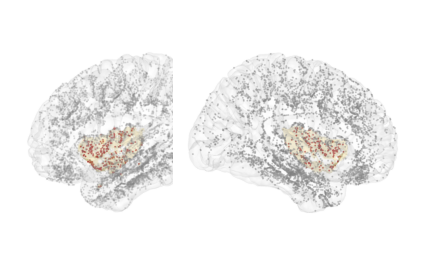

In [27]:
# cvs_avg35_inMNI152 visualization — template coords from package_ave_cord.py
# aparc labels for cortex validity; Hammers six-gyrus union for insula highlight
labels = mne.read_labels_from_annot(
    subject=FS_SUBJECT, parc='aparc.a2009s',
    surf_name='pial', hemi='both', subjects_dir=recon_dir,
)

lh_brain = Brain(
    FS_SUBJECT, subjects_dir=recon_dir, surf='pial',
    hemi='lh', background='white', show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600 * cm, 600 * cm),
)
rh_brain = Brain(
    FS_SUBJECT, subjects_dir=recon_dir, surf='pial',
    hemi='rh', background='white', show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600 * cm, 600 * cm),
)

cord = coords_unique[['x', 'y', 'z']].values
insula_mask_arr = coords_unique['is_insula'].values

lh_pial_path = f'{recon_dir}/{FS_SUBJECT}/surf/lh.pial'
rh_pial_path = f'{recon_dir}/{FS_SUBJECT}/surf/rh.pial'
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
lh_tree = cKDTree(lh_coords_pial)
rh_tree = cKDTree(rh_coords_pial)

electrode_color = 'gray'
insula_electrode_color = red

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_is_insula = insula_mask_arr[mask_lh]
    _, lh_indices = lh_tree.query(lh_cord)
    lh_projected_coords = lh_coords_pial[lh_indices]

    valid_mask = np.zeros(len(lh_cord), dtype=bool)
    for i, idx in enumerate(lh_indices):
        for lab in labels:
            if lab.hemi == 'lh' and idx in lab.vertices:
                valid_mask[i] = True
                break

    if valid_mask.any():
        non_insula = valid_mask & (~lh_is_insula)
        insula_only = valid_mask & lh_is_insula
        if non_insula.any():
            cloud = pv.PolyData(lh_projected_coords[non_insula])
            lh_brain._renderer.plotter.add_mesh(
                cloud, render_points_as_spheres=True, point_size=10,
                color=electrode_color, lighting=False, smooth_shading=False, opacity=0.3,
            )
        if insula_only.any():
            cloud = pv.PolyData(lh_projected_coords[insula_only])
            lh_brain._renderer.plotter.add_mesh(
                cloud, render_points_as_spheres=True, point_size=10,
                color=insula_electrode_color, lighting=False, smooth_shading=False, opacity=0.9,
            )

if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_is_insula = insula_mask_arr[mask_rh]
    _, rh_indices = rh_tree.query(rh_cord)
    rh_projected_coords = rh_coords_pial[rh_indices]

    valid_mask = np.zeros(len(rh_cord), dtype=bool)
    for i, idx in enumerate(rh_indices):
        for lab in labels:
            if lab.hemi == 'rh' and idx in lab.vertices:
                valid_mask[i] = True
                break

    if valid_mask.any():
        non_insula = valid_mask & (~rh_is_insula)
        insula_only = valid_mask & rh_is_insula
        if non_insula.any():
            cloud = pv.PolyData(rh_projected_coords[non_insula])
            rh_brain._renderer.plotter.add_mesh(
                cloud, render_points_as_spheres=True, point_size=10,
                color=electrode_color, lighting=False, smooth_shading=False, opacity=0.5,
            )
        if insula_only.any():
            cloud = pv.PolyData(rh_projected_coords[insula_only])
            rh_brain._renderer.plotter.add_mesh(
                cloud, render_points_as_spheres=True, point_size=10,
                color=insula_electrode_color, lighting=False, smooth_shading=False, opacity=0.9,
            )

for lab in hammers_insula_highlight_labels:
    brain = lh_brain if lab.hemi == 'lh' else rh_brain
    brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)

for brain in (lh_brain, rh_brain):
    brain.show_view(view='lateral', distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16 * cm, 8 * cm), gridspec_kw={'width_ratios': [1, 1]},
)
plt.subplots_adjust(wspace=-0.5)
ax1.imshow(lh_brain.screenshot(mode='rgb'))
ax1.axis('off')
ax2.imshow(rh_brain.screenshot(mode='rgb'))
ax2.axis('off')

lh_brain.close()
rh_brain.close()

fig.savefig('../img/fig1/fig1_all_electrodes_projected.svg', dpi=300, bbox_inches='tight')

# Panel B: Insula electrode zoom (L/R top-down)

Monochrome and Hammers six-gyrus electrode views on the pial surface (no anatomical label overlay).


In [28]:
# Panel B helpers — insula zoom on cvs_avg35_inMNI152 pial surface
import re
from matplotlib.patches import Patch

lh_pial_coords, _ = mne.read_surface(f'{recon_dir}/{FS_SUBJECT}/surf/lh.pial')
rh_pial_coords, _ = mne.read_surface(f'{recon_dir}/{FS_SUBJECT}/surf/rh.pial')
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

# Hammers atlas: six insular gyri (same names L/R; 12 label strings total)
HAMMERS_GYRI = [
    'anterior pole',
    'anterior short gyrus',
    'middle short gyrus',
    'anterior long gyrus',
    'posterior short gyrus',
    'posterior long gyrus',
]
HAMMERS_GYRUS_LABELS = {
    'anterior pole': 'Anterior pole',
    'anterior short gyrus': 'Ant. short gyrus',
    'middle short gyrus': 'Mid. short gyrus',
    'anterior long gyrus': 'Ant. long gyrus',
    'posterior short gyrus': 'Post. short gyrus',
    'posterior long gyrus': 'Post. long gyrus',
}
HAMMERS_GYRUS_COLORS = dict(
    zip(HAMMERS_GYRI, sns.color_palette('tab10', len(HAMMERS_GYRI)))
)

# aparc.a2009s insula patterns — focal point matches viz/fig1.ipynb
INSULA_PATTERNS = [
    'G_insular_short', 'G_Ins_lg_and_S_cent_ins',
    'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup',
]


def _insula_center(hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in INSULA_PATTERNS):
            vertices.extend(lab.vertices)
    return pial_coords[vertices].mean(axis=0) if vertices else None


lh_insula_center = _insula_center('lh', lh_pial_coords)
rh_insula_center = _insula_center('rh', rh_pial_coords)


def _make_insula_brain(hemi):
    return Brain(
        FS_SUBJECT, subjects_dir=recon_dir, surf='pial',
        hemi=hemi, background='white', show=False,
        cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(800, 800),
    )


insula_electrodes = coords_unique.loc[coords_unique['is_insula']].copy()
print(f'Insula electrodes for Panel B: {len(insula_electrodes)}')


def hammers_insula_gyrus(label):
    """Parse Hammers gyrus from electrode label, e.g. 'insula anterior pole L'."""
    if pd.isna(label):
        return pd.NA
    text = str(label).strip()
    if not text or text == '0':
        return pd.NA
    match = re.search(r'insula\s+(.+?)\s+[LR]$', text, flags=re.I)
    if match:
        return match.group(1).strip().lower()
    return pd.NA


def _project_to_pial(cord, tree, pial_coords):
    _, indices = tree.query(cord)
    return pial_coords[indices]


def _add_electrodes_fixed(brain, coords_proj, colors, point_size=12):
    for i, pt in enumerate(coords_proj):
        color = colors[i]
        if color is None or (isinstance(color, float) and np.isnan(color)):
            continue
        cloud = pv.PolyData(pt.reshape(1, 3))
        brain._renderer.plotter.add_mesh(
            cloud, render_points_as_spheres=True,
            point_size=point_size, color=color, lighting=False,
        )


def plot_insula_electrode_panel(
    plot_df,
    *,
    colors,
    title,
    legend_handles=None,
    save_path=None,
):
    """L/R insula zoom with electrodes projected onto pial surface."""
    if plot_df.empty:
        print(f'Skip plot (no electrodes): {title}')
        return

    cord = plot_df[['x', 'y', 'z']].values
    mask_lh = cord[:, 0] < 0
    mask_rh = cord[:, 0] > 0

    lh_brain = _make_insula_brain('lh')
    rh_brain = _make_insula_brain('rh')

    if mask_lh.any():
        lh_proj = _project_to_pial(cord[mask_lh], lh_tree, lh_pial_coords)
        _add_electrodes_fixed(lh_brain, lh_proj, np.asarray(colors)[mask_lh])
    if mask_rh.any():
        rh_proj = _project_to_pial(cord[mask_rh], rh_tree, rh_pial_coords)
        _add_electrodes_fixed(rh_brain, rh_proj, np.asarray(colors)[mask_rh])

    lh_brain.show_view(
        azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center,
    )
    rh_brain.show_view(
        azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center,
    )

    fig, axes = plt.subplots(1, 2, figsize=(16 * cm, 8 * cm))
    axes[0].imshow(lh_brain.screenshot(mode='rgb'))
    axes[0].axis('off')
    axes[0].set_title('Left Insula', fontsize=fontsize)
    axes[1].imshow(rh_brain.screenshot(mode='rgb'))
    axes[1].axis('off')
    axes[1].set_title('Right Insula', fontsize=fontsize)

    if legend_handles:
        axes[0].legend(
            handles=legend_handles,
            loc='upper left', fontsize=fontsize - 1, framealpha=0.9,
        )

    plt.suptitle(f'{title} (n={len(plot_df)})', fontsize=fontsize)
    lh_brain.close()
    rh_brain.close()
    plt.tight_layout()

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'Saved {save_path}')

    plt.show()

Insula electrodes for Panel B: 442


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-13 18:32:08.549 ( 924.548s) [    7FC231A52740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x12f54c90): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

Saved ../img/fig1/fig1_insula_electrodes_monochrome.svg


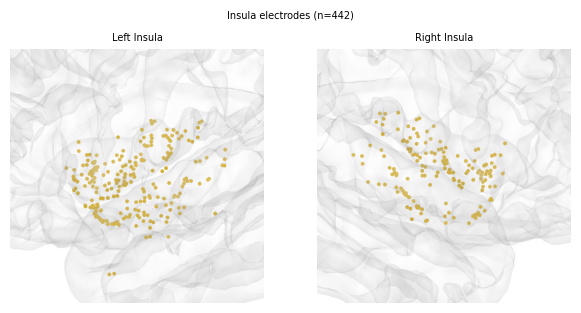

In [29]:
# Fig B1 — monochrome insula electrodes on pial surface
mono_colors = [insula_color] * len(insula_electrodes)

plot_insula_electrode_panel(
    insula_electrodes,
    colors=mono_colors,
    title='Insula electrodes',
    save_path='../img/fig1/fig1_insula_electrodes_monochrome.svg',
)

Skipping 82 electrodes without a Hammers gyrus label


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-13 18:32:10.731 ( 926.729s) [    7FC231A52740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x12e2c630): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

Saved ../img/fig1/fig1_insula_electrodes_hammers_six.svg


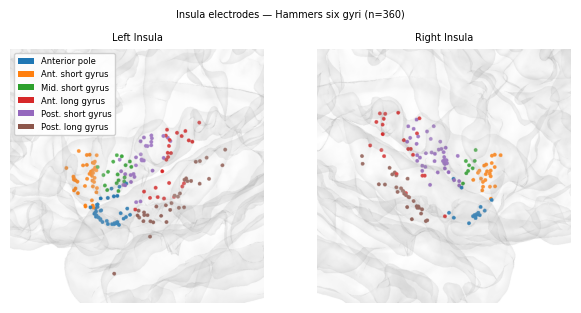

In [30]:
# Fig B2 — Hammers six insular gyri (electrode color by gyrus label)
insula_hammers = insula_electrodes.copy()
insula_hammers['hammers_gyrus'] = insula_hammers['label'].map(hammers_insula_gyrus)
insula_hammers = insula_hammers[insula_hammers['hammers_gyrus'].isin(HAMMERS_GYRI)].copy()

n_skip = len(insula_electrodes) - len(insula_hammers)
if n_skip:
    print(f'Skipping {n_skip} electrodes without a Hammers gyrus label')

gyrus_colors = insula_hammers['hammers_gyrus'].map(HAMMERS_GYRUS_COLORS).tolist()
present = [g for g in HAMMERS_GYRI if g in set(insula_hammers['hammers_gyrus'])]
legend_handles = [
    Patch(facecolor=HAMMERS_GYRUS_COLORS[g], label=HAMMERS_GYRUS_LABELS[g])
    for g in present
]

plot_insula_electrode_panel(
    insula_hammers,
    colors=gyrus_colors,
    title='Insula electrodes — Hammers six gyri',
    legend_handles=legend_handles,
    save_path='../img/fig1/fig1_insula_electrodes_hammers_six.svg',
)

## Significant HGA electrodes by phase

Pie charts of **mask==True** electrodes (`description=='Repeat'`) in stimulus (0–1 s), delay (0–1 s), and response (−0.5–0.5 s) windows. Hammers atlas; insula = pure AIC+PIC with `mix==False`.

In [31]:
# Load per-timepoint HGA stats (mask column lives in *_time.csv)
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})({atlas})',
            datatype='HGA',
            suffix='time',
            check=False,
        ).match()
    )

if not hga_paths:
    raise FileNotFoundError(
        f'No time CSVs under results/{{task}}({ref})({atlas})/ for tasks={task}'
    )

HGAs = pd.concat(
    [pd.read_csv(path) for path in tqdm(hga_paths, desc='load time')],
    ignore_index=True,
)

HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'
HGAs['phase'] = HGAs['phase'].str.lower()

# Hammers ROI groupings (same convention as vizpub fig2)
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'STGp', 'roi'] = 'STG'
HGAs.loc[HGAs.roi == 'STGa', 'roi'] = 'STG'
HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'

exclude_rois = {
    'Unknown', 'BrainStem', 'Thal', 'CC', 'Caud', 'Put', 'Amyg', 'Hipp',
    'LinG', 'Cun', 'mOccG', 'PhG', 'FuG', 'GRect', 'LatV', 'GSubcallosal',
    'Intersection', 'BrainStem–Thal',
}

phase_configs = {
    'stimulus': {'phase': 'stimulus', 'time_min': 0, 'time_max': 1},
    'delay': {'phase': 'delay', 'time_min': 0, 'time_max': 1},
    'response': {'phase': 'response', 'time_min': -0.5, 'time_max': 0.5},
}

ifg_color = blue


def filter_qc_electrodes(spatial):
    """Drop missing-annotation (label==0) and composite bipolar (mix) electrodes."""
    spatial = spatial.copy()
    if 'mix' in spatial.columns:
        spatial = spatial[~spatial['mix'].fillna(False).astype(bool)]
    if 'label' in spatial.columns:
        label_num = pd.to_numeric(spatial['label'], errors='coerce')
        spatial = spatial[~(label_num == 0)]
    return spatial


def _significant_spatial_for_phase(config):
    """Per-channel table for a phase/time window before QC/exclude filters."""
    mask = (
        (HGAs['phase'] == config['phase'])
        & (HGAs['description'] == 'Repeat')
        & (HGAs['time'] > config['time_min'])
        & (HGAs['time'] < config['time_max'])
        & (HGAs['mask'] == True)
    )
    return (
        HGAs[mask]
        .groupby('channel')
        .agg({'roi': 'first', 'mix': 'first', 'label': 'first'})
        .reset_index()
    )


def significant_channels_for_phase(config):
    """Unique significant channels in a phase/time window."""
    spatial = _significant_spatial_for_phase(config)
    spatial = filter_qc_electrodes(spatial)
    return spatial[~spatial.roi.isin(exclude_rois)].copy()


def phase_insula_vs_other():
    out = {}
    for phase_name, config in phase_configs.items():
        spatial = significant_channels_for_phase(config)
        insula_count = int(insula_mask(spatial, atlas).sum())
        total = len(spatial)
        out[phase_name] = {
            'insula': insula_count,
            'other': total - insula_count,
            'total': total,
        }
    return out


def phase_roi_breakdown():
    out = {}
    for phase_name, config in phase_configs.items():
        spatial = significant_channels_for_phase(config)
        spatial['category'] = np.select(
            [
                insula_mask(spatial, atlas),
                spatial['roi'] == 'STG',
                spatial['roi'] == 'SMC',
                spatial['roi'] == 'IFG',
            ],
            ['Insula', 'STG', 'SMC', 'IFG'],
            default='Other',
        )
        counts = spatial['category'].value_counts()
        out[phase_name] = {
            cat: int(counts.get(cat, 0))
            for cat in ['Insula', 'STG', 'SMC', 'IFG', 'Other']
        }
        out[phase_name]['total'] = len(spatial)
    return out


def significant_channels_union():
    """Unique significant channels active in any phase/time window."""
    frames = [
        significant_channels_for_phase(config)
        for config in phase_configs.values()
    ]
    return (
        pd.concat(frames, ignore_index=True)
        .drop_duplicates('channel')
        .reset_index(drop=True)
    )


def phase_insula_vs_other_union():
    spatial = significant_channels_union()
    insula_count = int(insula_mask(spatial, atlas).sum())
    total = len(spatial)
    return {'insula': insula_count, 'other': total - insula_count, 'total': total}


def phase_roi_breakdown_union():
    spatial = significant_channels_union()
    spatial['category'] = np.select(
        [
            insula_mask(spatial, atlas),
            spatial['roi'] == 'STG',
            spatial['roi'] == 'SMC',
            spatial['roi'] == 'IFG',
        ],
        ['Insula', 'STG', 'SMC', 'IFG'],
        default='Other',
    )
    counts = spatial['category'].value_counts()
    out = {
        cat: int(counts.get(cat, 0))
        for cat in ['Insula', 'STG', 'SMC', 'IFG', 'Other']
    }
    out['total'] = len(spatial)
    return out


def _remap_roi_column(df):
    spatial = df.copy()
    spatial.loc[spatial.roi == 'PrG', 'roi'] = 'SMC'
    spatial.loc[spatial.roi == 'PoG', 'roi'] = 'SMC'
    spatial.loc[spatial.roi == 'Subcentral', 'roi'] = 'SMC'
    spatial.loc[spatial.roi == 'STGp', 'roi'] = 'STG'
    spatial.loc[spatial.roi == 'STGa', 'roi'] = 'STG'
    spatial.loc[spatial.roi == 'HG', 'roi'] = 'STG'
    return spatial


def sampled_electrodes_spatial():
    """All unique sampled channels from coord CSVs (no mask filter), QC + exclude."""
    spatial = _remap_roi_column(coords_unique)
    spatial = filter_qc_electrodes(spatial)
    return spatial[~spatial.roi.isin(exclude_rois)].copy()


def sampling_roi_breakdown():
    spatial = sampled_electrodes_spatial()
    spatial['category'] = np.select(
        [
            insula_mask(spatial, atlas),
            spatial['roi'] == 'STG',
            spatial['roi'] == 'SMC',
            spatial['roi'] == 'IFG',
        ],
        ['Insula', 'STG', 'SMC', 'IFG'],
        default='Other',
    )
    counts = spatial['category'].value_counts()
    out = {
        cat: int(counts.get(cat, 0))
        for cat in ['Insula', 'STG', 'SMC', 'IFG', 'Other']
    }
    out['total'] = len(spatial)
    return out


def roi_significant_yield():
    """Per-ROI yield: significant_union / sampled (QC-filtered)."""
    sampled = sampling_roi_breakdown()
    significant = phase_roi_breakdown_union()
    category_order = ['Insula', 'STG', 'SMC', 'IFG', 'Other']
    out = {}
    for cat in category_order:
        n_sampled = sampled[cat]
        n_sig = significant[cat]
        out[cat] = {
            'sampled': n_sampled,
            'significant': n_sig,
            'yield_pct': 100.0 * n_sig / n_sampled if n_sampled else float('nan'),
        }
    out['total'] = {
        'sampled': sampled['total'],
        'significant': significant['total'],
        'yield_pct': (
            100.0 * significant['total'] / sampled['total']
            if sampled['total'] else float('nan')
        ),
    }
    return out


print('ROI mapping: STG <- {STGp, STGa, HG}; SMC <- {PrG, PoG, Subcentral}; IFG <- IFG')
print('QC filter: exclude label==0 and mix==True electrodes')
print('Per-phase QC counts (raw -> after QC -> final):')
for phase_name, config in phase_configs.items():
    spatial = _significant_spatial_for_phase(config)
    n_raw = len(spatial)
    spatial_qc = filter_qc_electrodes(spatial)
    n_qc = len(spatial_qc)
    n_final = len(spatial_qc[~spatial_qc.roi.isin(exclude_rois)])
    print(
        f'  {phase_name}: raw={n_raw} -> qc={n_qc} (-{n_raw - n_qc}) -> final={n_final}'
    )

union_raw = (
    pd.concat(
        [_significant_spatial_for_phase(cfg) for cfg in phase_configs.values()],
        ignore_index=True,
    )
    .drop_duplicates('channel')
)
n_union_raw = len(union_raw)
n_union_qc = len(filter_qc_electrodes(union_raw))
n_union_final = len(significant_channels_union())
print(
    f'Union QC counts: raw={n_union_raw} -> qc={n_union_qc} '
    f'(-{n_union_raw - n_union_qc}) -> final={n_union_final}'
)

print('Version 1:', phase_insula_vs_other())
print('Version 2:', phase_roi_breakdown())
print('Union v1:', phase_insula_vs_other_union())
print('Union v2:', phase_roi_breakdown_union())

_sampling_breakdown = sampling_roi_breakdown()
_sig_union_total = phase_roi_breakdown_union()['total']
print('Sampled electrodes (all tasks):', _sampling_breakdown)
print(
    f'Sampled vs significant union: '
    f'{_sampling_breakdown["total"]} sampled, {_sig_union_total} significant'
)

_yield_breakdown = roi_significant_yield()
print('Significant yield by ROI (% of sampled):')
for _cat in ['Insula', 'STG', 'SMC', 'IFG', 'Other']:
    _row = _yield_breakdown[_cat]
    print(
        f"  {_cat}: {_row['significant']}/{_row['sampled']} "
        f"({_row['yield_pct']:.1f}%)"
    )

load time: 100%|██████████| 1212/1212 [00:25<00:00, 48.35it/s]


ROI mapping: STG <- {STGp, STGa, HG}; SMC <- {PrG, PoG, Subcentral}; IFG <- IFG
QC filter: exclude label==0 and mix==True electrodes
Per-phase QC counts (raw -> after QC -> final):
  stimulus: raw=2607 -> qc=1595 (-1012) -> final=1353
  delay: raw=1818 -> qc=1135 (-683) -> final=994
  response: raw=3383 -> qc=1994 (-1389) -> final=1786
Union QC counts: raw=4479 -> qc=2647 (-1832) -> final=2250
Version 1: {'stimulus': {'insula': 112, 'other': 1241, 'total': 1353}, 'delay': {'insula': 98, 'other': 896, 'total': 994}, 'response': {'insula': 160, 'other': 1626, 'total': 1786}}
Version 2: {'stimulus': {'Insula': 112, 'STG': 295, 'SMC': 121, 'IFG': 84, 'Other': 741, 'total': 1353}, 'delay': {'Insula': 98, 'STG': 216, 'SMC': 91, 'IFG': 67, 'Other': 522, 'total': 994}, 'response': {'Insula': 160, 'STG': 283, 'SMC': 223, 'IFG': 95, 'Other': 1025, 'total': 1786}}
Union v1: {'insula': 201, 'other': 2049, 'total': 2250}
Union v2: {'Insula': 201, 'STG': 331, 'SMC': 242, 'IFG': 128, 'Other': 1348, '

### Version 1 — Insula vs Other ROIs


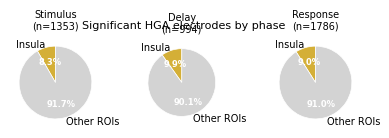

In [32]:
phase_data = phase_insula_vs_other()
max_count = max(data['total'] for data in phase_data.values())
widths = [
    np.sqrt(phase_data[phase]['total'] / max_count)
    for phase in ['stimulus', 'delay', 'response']
]

fig = plt.figure(figsize=(12 * cm, 3 * cm))
gs = fig.add_gridspec(1, 3, width_ratios=widths, wspace=0.35)

for idx, (phase_name, data) in enumerate(phase_data.items()):
    ax = fig.add_subplot(gs[idx])
    sizes = [data['insula'], data['other']]
    labels = ['Insula', 'Other ROIs']
    colors = [insula_color, 'lightgray']

    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': fontsize},
        wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'},
    )

    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(6)

    ax.set_title(f'{phase_name.capitalize()}\n(n={data["total"]})', fontsize=fontsize)

plt.suptitle('Significant HGA electrodes by phase', fontsize=8, y=1.02)
Path('../img/fig1').mkdir(parents=True, exist_ok=True)
fig.savefig('../img/fig1/fig1_phase_insula_vs_other.svg', dpi=300, bbox_inches='tight')
plt.show()

### Version 2 — Insula + STG + SMC + IFG + Other


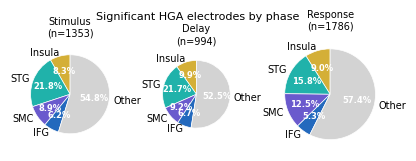

In [33]:
breakdown_data = phase_roi_breakdown()
max_count = max(data['total'] for data in breakdown_data.values())
widths = [
    np.sqrt(breakdown_data[phase]['total'] / max_count)
    for phase in ['stimulus', 'delay', 'response']
]

category_order = ['Insula', 'STG', 'SMC', 'IFG', 'Other']
category_colors = {
    'Insula': insula_color,
    'STG': stg_color,
    'SMC': smc_color,
    'IFG': ifg_color,
    'Other': 'lightgray',
}

fig = plt.figure(figsize=(12 * cm, 4 * cm))
gs = fig.add_gridspec(1, 3, width_ratios=widths, wspace=0.35)

for idx, (phase_name, data) in enumerate(breakdown_data.items()):
    ax = fig.add_subplot(gs[idx])
    sizes = [data[cat] for cat in category_order]
    labels = category_order
    colors = [category_colors[cat] for cat in category_order]

    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': fontsize},
        wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'},
    )

    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(6)

    ax.set_title(f'{phase_name.capitalize()}\n(n={data["total"]})', fontsize=fontsize)

plt.suptitle('Significant HGA electrodes by phase', fontsize=8, y=1.02)
fig.savefig('../img/fig1/fig1_phase_roi_breakdown.svg', dpi=300, bbox_inches='tight')
plt.show()

### Union across phases — significant in any phase

Single pie chart: electrode is **active** if `mask==True` in stimulus, delay, or response (union across phases).


Union Insula vs Other: {'insula': 201, 'other': 2049, 'total': 2250}
Union ROI breakdown: {'Insula': 201, 'STG': 331, 'SMC': 242, 'IFG': 128, 'Other': 1348, 'total': 2250}


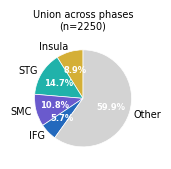

In [34]:
union_breakdown = phase_roi_breakdown_union()
union_insula_other = phase_insula_vs_other_union()
print('Union Insula vs Other:', union_insula_other)
print('Union ROI breakdown:', union_breakdown)

category_order = ['Insula', 'STG', 'SMC', 'IFG', 'Other']
category_colors = {
    'Insula': insula_color,
    'STG': stg_color,
    'SMC': smc_color,
    'IFG': ifg_color,
    'Other': 'lightgray',
}

fig, ax = plt.subplots(figsize=(4 * cm, 4 * cm))
sizes = [union_breakdown[cat] for cat in category_order]
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=category_order,
    colors=[category_colors[cat] for cat in category_order],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': fontsize},
    wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'},
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(6)
ax.set_title(
    f'Union across phases\n(n={union_breakdown["total"]})',
    fontsize=fontsize,
)
Path('../img/fig1').mkdir(parents=True, exist_ok=True)
fig.savefig('../img/fig1/fig1_phase_roi_breakdown_union.svg', dpi=300, bbox_inches='tight')
plt.show()

### Sampled electrode coverage by ROI

All unique channels from coord CSVs (union across tasks), without requiring `mask==True`. Same QC (`label==0`, `mix==True` excluded) and ROI grouping as the significant-electrode pies above.

Sampled ROI breakdown: {'Insula': 360, 'STG': 456, 'SMC': 406, 'IFG': 214, 'Other': 3060, 'total': 4496}


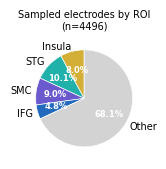

In [35]:
sampling_breakdown = sampling_roi_breakdown()
print('Sampled ROI breakdown:', sampling_breakdown)

category_order = ['Insula', 'STG', 'SMC', 'IFG', 'Other']
category_colors = {
    'Insula': insula_color,
    'STG': stg_color,
    'SMC': smc_color,
    'IFG': ifg_color,
    'Other': 'lightgray',
}

fig, ax = plt.subplots(figsize=(4 * cm, 4 * cm))
sizes = [sampling_breakdown[cat] for cat in category_order]
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=category_order,
    colors=[category_colors[cat] for cat in category_order],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': fontsize},
    wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'},
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(6)
ax.set_title(
    f'Sampled electrodes by ROI\n(n={sampling_breakdown["total"]})',
    fontsize=fontsize,
)
Path('../img/fig1').mkdir(parents=True, exist_ok=True)
fig.savefig('../img/fig1/fig1_sampling_roi_breakdown.svg', dpi=300, bbox_inches='tight')
plt.show()

### Significant yield by ROI

Among **sampled** electrodes (QC filtered), fraction with significant HGA in any phase. Addresses whether smaller Insula share in the union pie reflects lower sampling vs lower activation rate.


category  sampled  significant yield_pct
  Insula      360          201     55.8%
     STG      456          331     72.6%
     SMC      406          242     59.6%
     IFG      214          128     59.8%
   Other     3060         1348     44.1%


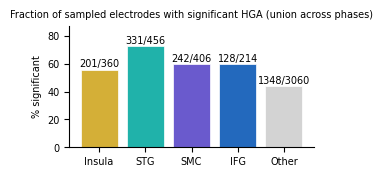

In [36]:
yield_breakdown = roi_significant_yield()
category_order = ['Insula', 'STG', 'SMC', 'IFG', 'Other']
category_colors = {
    'Insula': insula_color,
    'STG': stg_color,
    'SMC': smc_color,
    'IFG': ifg_color,
    'Other': 'lightgray',
}

yield_table = pd.DataFrame(
    [
        {
            'category': cat,
            'sampled': yield_breakdown[cat]['sampled'],
            'significant': yield_breakdown[cat]['significant'],
            'yield_pct': yield_breakdown[cat]['yield_pct'],
        }
        for cat in category_order
    ]
)
print(yield_table.to_string(index=False, formatters={'yield_pct': '{:.1f}%'.format}))

fig, ax = plt.subplots(figsize=(8 * cm, 4 * cm))
yields = [yield_breakdown[cat]['yield_pct'] for cat in category_order]
bars = ax.bar(
    category_order,
    yields,
    color=[category_colors[cat] for cat in category_order],
    edgecolor='white',
    linewidth=0.5,
)
for bar, cat in zip(bars, category_order):
    row = yield_breakdown[cat]
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{row['significant']}/{row['sampled']}",
        ha='center',
        va='bottom',
        fontsize=fontsize,
    )
ax.set_ylabel('% significant', fontsize=fontsize)
ax.set_title(
    'Fraction of sampled electrodes with significant HGA (union across phases)',
    fontsize=fontsize,
)
ax.tick_params(axis='both', labelsize=fontsize)
ax.set_ylim(0, max(yields) * 1.2 if yields else 100)
sns.despine(ax=ax)
Path('../img/fig1').mkdir(parents=True, exist_ok=True)
fig.savefig('../img/fig1/fig1_roi_significant_yield.svg', dpi=300, bbox_inches='tight')
plt.show()

## TFR — example electrode (placeholder)

*Upcoming panel:* time–frequency plot for representative electrode(s) tied to the phase breakdown above. Electrode selection and plotting code to be added.